# Attention & self attention

https://arxiv.org/abs/1706.03762 - статья Attention is all you need

https://jalammar.github.io/illustrated-transformer/ - блог Jay Alamar с визуализацией

В этом ноутбуке будет использоваться softmax из pytorch 

https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.softmax.html

In [396]:
import torch
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

import torch.nn.functional as F

## Эмбеддинги

n = 5 (размерность эмбеддинга)

s = 3 (длина последовательности)

d = 4 (размерность QKV векторов)

## Dot-product Attention (классическая идея)

Изначально attention mechanism появился при решении задач seq2seq. Обычные итеративные алгоритмы (в стиле RNN) не позволяют сохранять контекст (предыдущие состояния в последовательности) достаточно долго для языкового моделирования из-за затухания градиентов. 

Допустим, у нас есть последовательность векторов длины s: $h_i, \,\,\, i = \overline{1,s}$ (здесь $h_i$ - это скрытое состояние RNN, в каком то смысле эмбед). Важный момент, в идеале внутренние состояния имеют примерно одинаковую норму:
$$ \forall i, j \,\,\, \vert h_i \vert \approx \vert h_j \vert $$

В ранних архитекурах для этого использовалось куча костылей.

Идейно внимание позволяет оценить насколько один вектор похож на другой, это просто скалярное произведение:

$$ e_{ij} = h_i^T h_j $$

Attention scores - это софтмакс от таких скалярных произведений с вектором $h_{s+1}$.

$$ \alpha_{i} = softmax(h_i^T h_{s+1}) $$

Вычислим взвешенную сумму по $\alpha_{i}$ (буквально по значимости для $h_{s+1}$) и получим итоговый вектор контекста для состояния $h_{s+1}$

$$ z = \sum_i \alpha_i h_i $$

Затем в RNN вектор $z$ обычно конкатенируется с $h_{s+1}$ и подается на линейный слой для предсказания логитов на следующий токен.

Сложим вектора $h_i$ в матрицу H и назовем $h_{s+1}$ таргетом (t):

$$ H \in \mathbb{R}^{s \times n}, \;\;\;\; t \in \mathbb{R}^{n}$$

$$ z = H^T softmax(Ht) \in \mathbb{R}^n $$




In [397]:
n = 6

emb1 = torch.tensor([1, 2, 3, 4, 5, 6], dtype=torch.float64)
emb2 = torch.tensor([1, 2, 3, 4, 5, 6], dtype=torch.float64) + torch.randn((n)) * 0.2 # небольшой шум
emb3 = torch.randn((n))
target = torch.tensor([1, 2, 3, 4, 5, 6], dtype=torch.float64)

# Нормировка
emb1 = emb1 / torch.linalg.norm(emb1)
emb2 = emb2 / torch.linalg.norm(emb2)
emb3 = emb3 / torch.linalg.norm(emb3)
target = target / torch.linalg.norm(target)

context = torch.stack([emb1, emb2, emb3]) # (3, 5)
print(context)
print(context.size())

print(target)

tensor([[ 0.1048,  0.2097,  0.3145,  0.4193,  0.5241,  0.6290],
        [ 0.1130,  0.2144,  0.3225,  0.4283,  0.5055,  0.6311],
        [ 0.8655, -0.2501,  0.1810,  0.1048,  0.2097,  0.3172]],
       dtype=torch.float64)
torch.Size([3, 6])
tensor([0.1048, 0.2097, 0.3145, 0.4193, 0.5241, 0.6290], dtype=torch.float64)


In [398]:
emb4 = torch.tensor([1, 1, 1, 1, 1, -2.5], dtype=torch.float64) # для теста ортогональный к таргету
emb4 = emb4 / torch.linalg.norm(emb4)
print(emb1.T @ emb4)
#context = torch.stack([emb1, emb2, emb4])

tensor(5.5511e-17, dtype=torch.float64)


In [399]:
emb5 = torch.tensor([-1, -2, -3, -4, -5, -6], dtype=torch.float64) # для теста противоположный к таргету
emb5 = emb5 / torch.linalg.norm(emb5)
print(emb1.T @ emb5)
#context = torch.stack([emb1, emb2, emb5])

tensor(-1., dtype=torch.float64)


In [400]:
def attention(context, target):
    scores = context @ target
    soft_scores = F.softmax(scores, dim=0)
    return soft_scores

In [401]:
print(context)
print(target)
attention(context, target)

tensor([[ 0.1048,  0.2097,  0.3145,  0.4193,  0.5241,  0.6290],
        [ 0.1130,  0.2144,  0.3225,  0.4283,  0.5055,  0.6311],
        [ 0.8655, -0.2501,  0.1810,  0.1048,  0.2097,  0.3172]],
       dtype=torch.float64)
tensor([0.1048, 0.2097, 0.3145, 0.4193, 0.5241, 0.6290], dtype=torch.float64)


tensor([0.3882, 0.3881, 0.2237], dtype=torch.float64)

emb1 - точная копия - наибольший вес

emb2 - копия с шумом - вес чуть меньше

emb3 - рандомный вектор - вес сильно меньше



In [402]:
z = context.T @ attention(context, target)
z # средневзвешенная контекста по attention скорам

tensor([0.2781, 0.1087, 0.2877, 0.3524, 0.4466, 0.5601], dtype=torch.float64)

## Self Attention

### Схожесть с оригинальным attention

Для каждого эмбеда формируются Qwery Key и Value вектора. Key и qwery обычно меньшей размерности чем сам эмбеддинг $e$, вектор value имеет ту же размерность что и $e$ (идейно для values вычисляется взыешенная сумма с весами вычисленными при помощи q и k векторов): 

$$ q, k, \in \mathbb{R}^d,\;\;  v \in \mathbb{R}^n $$

Вектора q k и v для каждого эмбеда формируются через обучаемые матрицы весов:

$$W_q, W_k \in \mathbb{R}^{n \times d},\;\;  W_v \in \mathbb{R}^{n \times n} ,\;\;  e  \in \mathbb{R}^n$$

$$q = W_q^T e \;\;\;\; k = W_k^T e \;\;\;\; v = W_v^T e$$

Вычисления обычно записываются в матричном виде, для всей последовательности сразу, $C$ - контекст:

$$ C  \in \mathbb{R}^{s \times n} \;\;  Q, K \in \mathbb{R}^{s \times d} \;\; V \in \mathbb{R}^{s \times n}$$

$$Q = C W_q \;\;\;\; K = C W_k \;\;\;\; V = C W_v$$

Идейно почти то же самое: qwery - таргет (откуда смотрим), key - контекст (куда смотрим), из них вычисляется attention score и умножается на value вместо оригинального эмбеда. 

$$Attention(q, K, V) = V^T  softmax(K q) \in \mathbb{R}^{n}$$

Здесь $Attention(q, K, V)$ - это новый эмбеддинг в том же пространстве $\mathbb{R}^n$, $softmax(K q)$ - attention скоры

Если записать сразу для каждого токена в последовательности

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

Деление на $\sqrt{d_k}$ нужно для стабилизации градиентов: скалярные произведения растут с ростом размерности, и без масштабирования softmax попадает в зону насыщения.

В оригинальной статье и в литературе d_model (обозначено за n) - размерность эмбеддинга на входе, d_k (обозначено за d) - размерность q и k векторов.  


In [403]:
s = 3
d_k = 4

In [404]:
def self_attention_simple(query, keys, values):
    scores = keys @ query
    weights = F.softmax(scores, dim=0)
    out = values.T @ weights
    return out, weights

In [405]:
d_k = 4
Wq = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wk = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wv = torch.tensor(np.random.random((n, n)), dtype=torch.float64)

In [406]:
print(context.size())

K = context @ Wk
V = context @ Wv
q = Wq.T @ target

out, w = self_attention_simple(q, K, V)
print(out)
print(w)

torch.Size([3, 6])
tensor([0.5855, 0.9841, 1.3397, 1.3761, 1.1457, 0.5621], dtype=torch.float64)
tensor([0.4076, 0.4181, 0.1744], dtype=torch.float64)


In [407]:
def self_attention(Q, K, V, d_k): # для каждого токена
    scores = Q @ K.T
    scores = scores / torch.sqrt(d_k)
    weights = F.softmax(scores, dim=0)
    out = weights @ V
    return out, weights

In [408]:
K = context @ Wk
V = context @ Wv
Q = context @ Wq

out, w = self_attention(Q, K, V, d_k=torch.tensor(d_k))
print(out)
print(w)

tensor([[0.5809, 0.8590, 1.3675, 1.3480, 1.1706, 0.6241],
        [0.5899, 0.8729, 1.3884, 1.3688, 1.1885, 0.6334],
        [0.5499, 0.8081, 1.2962, 1.2753, 1.1096, 0.5937]], dtype=torch.float64)
tensor([[0.3386, 0.3384, 0.3355],
        [0.3442, 0.3440, 0.3398],
        [0.3172, 0.3176, 0.3247]], dtype=torch.float64)


<Axes: >

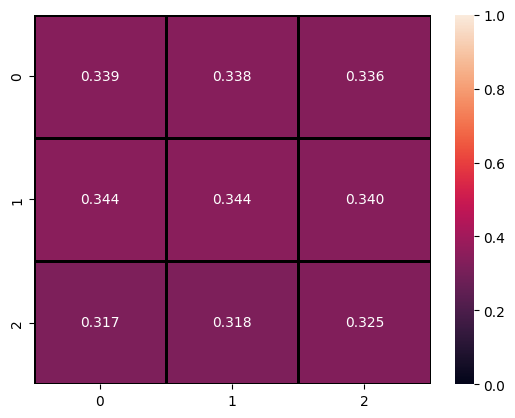

In [409]:
#Так называемая матрица attention показывает, насколько каждый токен контекста важен для другого
import seaborn as sns

sns.heatmap(
    w.numpy(),
    annot=True,
    fmt=".3f",
    linewidths=2,
    linecolor="black",
    vmin=0,
    vmax=1,
)

## Masked self-attention

В авторегрессионных моделях токен не должен видеть будущее.
Для этого в матрице оценок маскируются элементы выше главной диагонали ($-\infty$).

После softmax $-\infty$ превращается в что то около нулевое — токен не получает информацию из будущего.


In [410]:
def masked_self_attention(Q, K, V, d_k, s): # для каждого токена
    scores = Q @ K.T
    scores = scores / torch.sqrt(d_k)

    mask = torch.triu(torch.ones(s, s, dtype=torch.bool), diagonal=1)
    scores = scores.masked_fill(mask, float('-inf'))
    
    weights = F.softmax(scores, dim=0)
    out = weights @ V
    return out, weights, mask

In [411]:
out, w, mask = masked_self_attention(Q, K, V, d_k=torch.tensor(d_k), s=context.shape[0])
print(mask)
print(out)
print(w)


tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])
tensor([[0.2006, 0.3842, 0.4488, 0.4817, 0.3835, 0.1675],
        [0.5183, 0.9807, 1.1477, 1.2328, 0.9804, 0.4347],
        [1.0018, 1.1750, 2.4556, 2.2777, 2.1047, 1.2489]], dtype=torch.float64)
tensor([[0.3386, 0.0000, 0.0000],
        [0.3442, 0.5200, 0.0000],
        [0.3172, 0.4800, 1.0000]], dtype=torch.float64)


<Axes: >

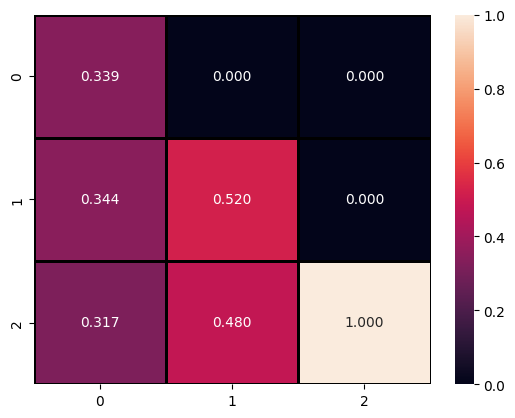

In [412]:
sns.heatmap(
    w.numpy(),
    annot=True,
    fmt=".3f",
    linewidths=2,
    linecolor="black",
    vmin=0,
    vmax=1,
)

## Multi-head attention

Сам по себе attention механизм может не уловить важные связи между токенами. Чтобы снизить такую вероятность, делают несколько голов с собственными $W_q, W_k, W_v$ матрицами, которые будут независимо считать self-attention. В такой конфигурации механизм остается почти таким же, но размерность вектора value обычно берут $d_v = d_{model} / n_{heads}$ (размерность эмбеддинга делить на количество голов), но можно увидеть и другие варианты.

Объединить головы довольно просто: выходы голов конкатенируются (размерность выхода одной головы $\mathbb{R}^{s \times d_v}$), получается $\mathbb{R}^{s \times d_v*n_{heads}}$. Чтобы привести результат к изначальной размерности эмбеддинга, используют output матрицу $W_O$ размерности:

$$ W_O \in \mathbb{R}^{n_{heads}*d_v \times d_{model}} $$

$$\text{MultiHead}(C) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W_O$$


In [413]:
d_k = 4
d_v = 4 # обычно берут n / n_heads, но для демонстрации пойдет
n_heads = 2

Wq1 = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wk1 = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wv1 = torch.tensor(np.random.random((n, d_v)), dtype=torch.float64)

Wq2 = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wk2 = torch.tensor(np.random.random((n, d_k)), dtype=torch.float64)
Wv2 = torch.tensor(np.random.random((n, d_v)), dtype=torch.float64)

W0 = torch.tensor(np.random.random((n_heads * d_v, n)), dtype=torch.float64)

In [414]:
K1 = context @ Wk1
V1 = context @ Wv1
Q1 = context @ Wq1

K2 = context @ Wk2
V2 = context @ Wv2
Q2 = context @ Wq2

out1, w1 = self_attention(Q1, K1, V1, d_k=torch.tensor(d_k))
out2, w2 = self_attention(Q2, K2, V2, d_k=torch.tensor(d_k))
z = torch.concat([out1, out2], dim=1)
z

tensor([[0.6106, 0.7128, 1.8152, 0.7481, 1.0167, 0.7554, 1.1420, 1.0871],
        [0.6206, 0.7240, 1.8421, 0.7605, 1.0312, 0.7673, 1.1599, 1.1033],
        [0.3398, 0.4097, 1.0950, 0.4142, 0.6864, 0.4988, 0.7556, 0.7274]],
       dtype=torch.float64)

In [415]:
z @ W0

tensor([[5.8891, 5.4774, 5.4425, 4.7433, 3.0847, 4.3798],
        [5.9786, 5.5614, 5.5263, 4.8162, 3.1317, 4.4460],
        [3.7105, 3.3704, 3.3665, 3.0106, 1.9554, 2.7389]], dtype=torch.float64)

### Матрицы внимания голов

<Axes: >

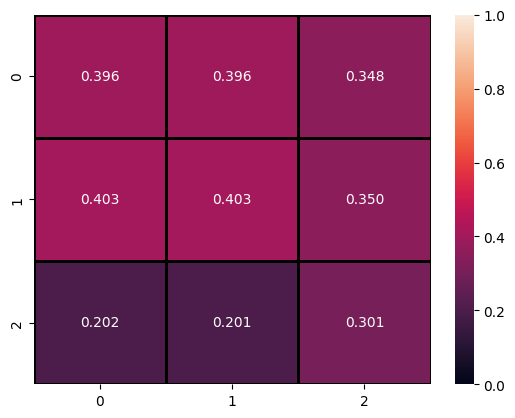

In [416]:
sns.heatmap(
    w1.numpy(),
    annot=True,
    fmt=".3f",
    linewidths=2,
    linecolor="black",
    vmin=0,
    vmax=1,
)

<Axes: >

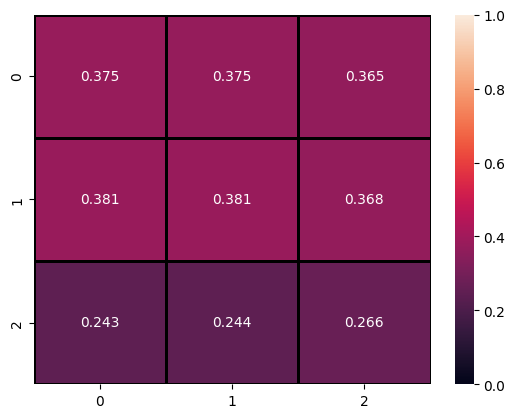

In [417]:
sns.heatmap(
    w2.numpy(),
    annot=True,
    fmt=".3f",
    linewidths=2,
    linecolor="black",
    vmin=0,
    vmax=1,
)